# 📊 Regression Metrics & Cross-Validation
### A Complete Lecture Guide with Examples & Visualizations

---

> **Goal:** Understand how we measure how *good* or *bad* a regression model is — and how to make those measurements *trustworthy*.

### 🗺️ What We'll Cover
| # | Topic |
|---|-------|
| 1 | Setup & Dataset |
| 2 | Mean Absolute Error (MAE) |
| 3 | Mean Squared Error (MSE) |
| 4 | Root Mean Squared Error (RMSE) |
| 5 | R² (Coefficient of Determination) |
| 6 | Side-by-Side Metric Comparison |
| 7 | Cross-Validation – Making Metrics Reliable |

---
## 🔧 Section 0 — Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('husl')
print('✅ All libraries loaded!')

✅ All libraries loaded!


---
## 🏠 Section 1 — Our Story Dataset: House Price Prediction

We'll use a **simple house price dataset** throughout.

- **Input (X):** House size in square feet  
- **Output (y):** House price in $1000s  

We have **two models** to compare:
- 🟢 **Good Model** — predictions close to truth
- 🔴 **Bad Model** — predictions far off, with some big blunders

In [2]:
np.random.seed(42)
n = 20

# True house prices (ground truth)
y_true = np.array([150, 180, 200, 220, 160, 300, 250, 190, 210, 280,
                   170, 240, 260, 310, 195, 230, 175, 290, 215, 245])

# Good model: small, consistent errors
y_good = y_true + np.random.normal(0, 12, n)

# Bad model: larger errors, including a few HUGE mistakes
y_bad  = y_true + np.random.normal(0, 35, n)
y_bad[[3, 11, 17]] += np.array([80, -90, 100])  # deliberate big outlier errors

houses = pd.DataFrame({'True_Price': y_true,
                        'Good_Model': np.round(y_good, 1),
                        'Bad_Model':  np.round(y_bad,  1)})
houses['Error_Good'] = houses['Good_Model'] - houses['True_Price']
houses['Error_Bad']  = houses['Bad_Model']  - houses['True_Price']

print('📋 First 8 rows of our dataset:')
houses.head(8).style.format('{:.1f}').background_gradient(cmap='RdYlGn', subset=['Error_Good','Error_Bad'])

📋 First 8 rows of our dataset:


,True_Price,Good_Model,Bad_Model,Error_Good,Error_Bad
0,150.0,156.0,201.3,6.0,51.3
1,180.0,178.3,172.1,-1.7,-7.9
2,200.0,207.8,202.4,7.8,2.4
3,220.0,238.3,250.1,18.3,30.1
4,160.0,157.2,140.9,-2.8,-19.1
5,300.0,297.2,303.9,-2.8,3.9
6,250.0,269.0,209.7,19.0,-40.3
7,190.0,199.2,203.1,9.2,13.1


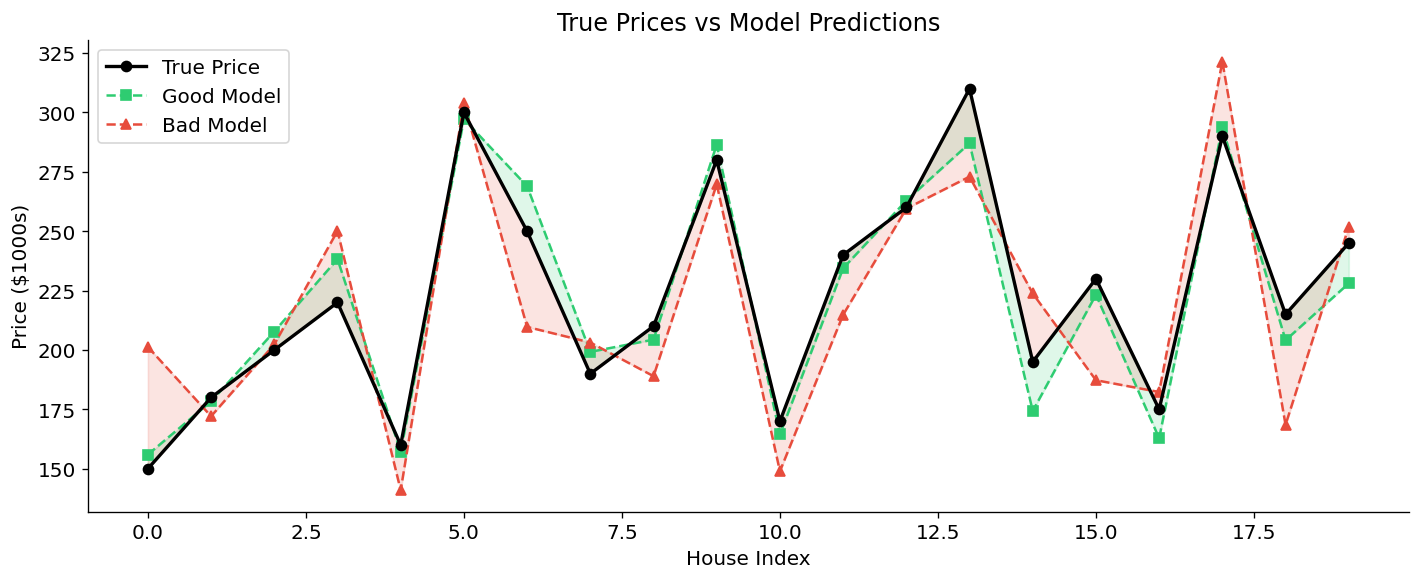

💡 The shaded area = errors. Bigger shading = worse model.


In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(n)
ax.plot(x, y_true, 'ko-', lw=2, label='True Price', zorder=5)
ax.plot(x, y_good, 's--', color='#2ecc71', lw=1.5, label='Good Model')
ax.plot(x, y_bad,  '^--', color='#e74c3c', lw=1.5, label='Bad Model')
ax.fill_between(x, y_true, y_good, alpha=0.15, color='#2ecc71')
ax.fill_between(x, y_true, y_bad,  alpha=0.15, color='#e74c3c')
ax.set(xlabel='House Index', ylabel='Price ($1000s)',
       title='True Prices vs Model Predictions')
ax.legend()
plt.tight_layout()
plt.show()
print('💡 The shaded area = errors. Bigger shading = worse model.')

---
## 📏 Section 2 — Mean Absolute Error (MAE)

### 🧠 Intuition
> *"On average, how far off are my predictions?"*

### 📐 Formula
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

### ✅ Key Properties
| Property | Detail |
|----------|--------|
| Units | Same as target (\$1000s) |
| Outlier sensitivity | **Low** — treats all errors equally |
| Interpretability | Very easy — it's just an average distance |
| Best when | You want a robust, easy-to-explain metric |

In [4]:
# --- Step-by-step MAE calculation ---
errors_good = np.abs(y_true - y_good)
errors_bad  = np.abs(y_true - y_bad)

mae_good = errors_good.mean()
mae_bad  = errors_bad.mean()

# Verify with sklearn
assert np.isclose(mae_good, mean_absolute_error(y_true, y_good))

print('=== MAE Step-by-Step (Good Model) ===')
print(f'  Absolute errors: {np.round(errors_good[:5], 1)} ...')
print(f'  Sum of abs errors: {errors_good.sum():.1f}')
print(f'  MAE = {errors_good.sum():.1f} / {n} = {mae_good:.2f} ($1000s)\n')

print(f'🟢 Good Model MAE: ${mae_good:.2f}K  →  avg error = ${mae_good*1000:.0f}')
print(f'🔴 Bad  Model MAE: ${mae_bad:.2f}K   →  avg error = ${mae_bad*1000:.0f}')

=== MAE Step-by-Step (Good Model) ===
  Absolute errors: [ 6.   1.7  7.8 18.3  2.8] ...
  Sum of abs errors: 187.8
  MAE = 187.8 / 20 = 9.39 ($1000s)

🟢 Good Model MAE: $9.39K  →  avg error = $9391
🔴 Bad  Model MAE: $22.33K   →  avg error = $22332


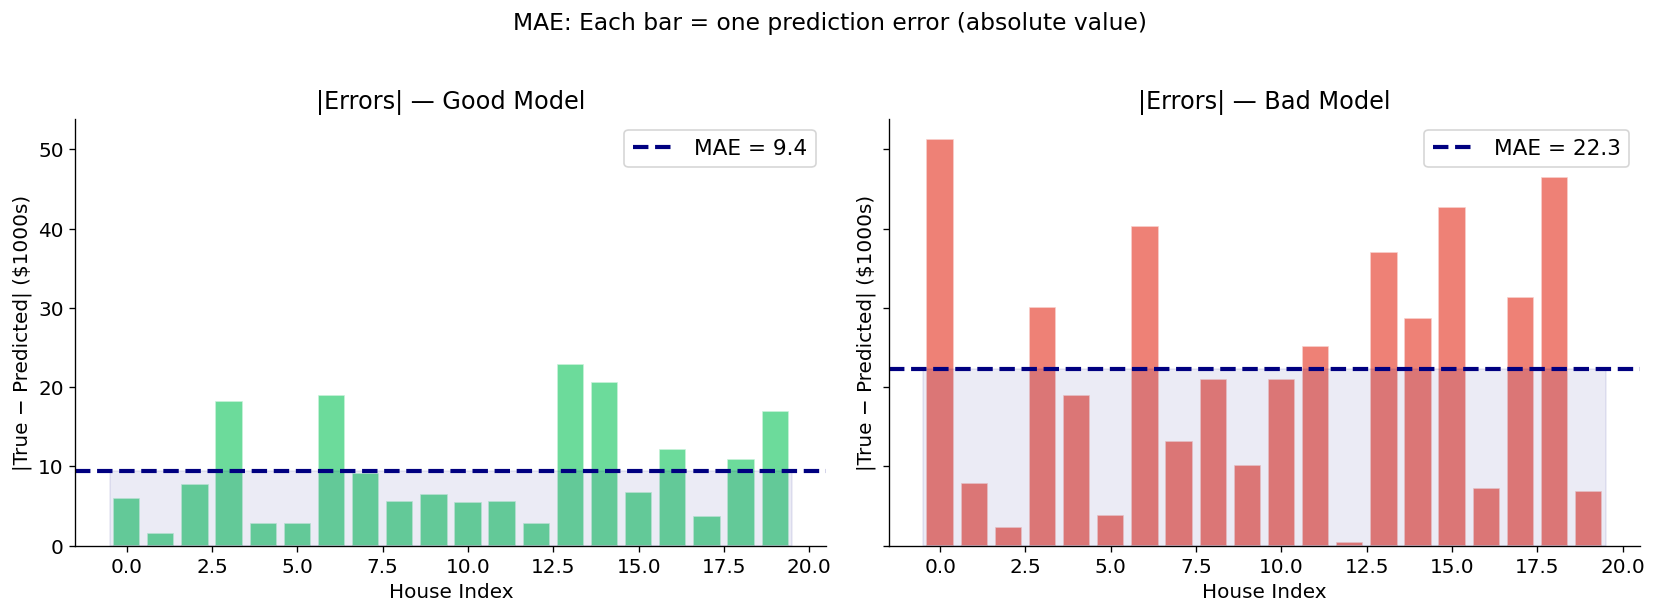

💡 The dashed line is the MAE — it is the average height of all bars.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, errors, label, color, mae in zip(
        axes,
        [errors_good, errors_bad],
        ['Good Model', 'Bad Model'],
        ['#2ecc71', '#e74c3c'],
        [mae_good, mae_bad]):
    
    bars = ax.bar(range(n), errors, color=color, alpha=0.7, edgecolor='white')
    ax.axhline(mae, color='navy', lw=2.5, ls='--', label=f'MAE = {mae:.1f}')
    ax.fill_between([-0.5, n-0.5], 0, mae, color='navy', alpha=0.08)
    ax.set(title=f'|Errors| — {label}', xlabel='House Index',
           ylabel='|True − Predicted| ($1000s)')
    ax.legend(fontsize=13)

plt.suptitle('MAE: Each bar = one prediction error (absolute value)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print('💡 The dashed line is the MAE — it is the average height of all bars.')

---
## 📐 Section 3 — Mean Squared Error (MSE)

### 🧠 Intuition
> *"Same idea as MAE, but we SQUARE the errors first — so big mistakes are punished much harder!"*

### 📐 Formula
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### ✅ Key Properties
| Property | Detail |
|----------|--------|
| Units | **Squared** units (\$² × 1000²) — harder to interpret directly |
| Outlier sensitivity | **High** — squares amplify big errors |
| Role in ML | Used as the **loss function** during training |
| Best when | You want to heavily penalize large errors |

In [6]:
sq_errors_good = (y_true - y_good)**2
sq_errors_bad  = (y_true - y_bad)**2

mse_good = sq_errors_good.mean()
mse_bad  = sq_errors_bad.mean()

print(f'🟢 Good Model MSE: {mse_good:.1f}  (squared $1000 units)')
print(f'🔴 Bad  Model MSE: {mse_bad:.1f}  (squared $1000 units)\n')

# Show WHY squaring matters — look at the outlier houses
print('--- Effect of squaring on outlier vs small error ---')
small_err = 5   # $5K off
big_err   = 90  # $90K off (outlier)
print(f'Small error (${small_err}K):  |e| = {small_err},  e² = {small_err**2}')
print(f'Big error   (${big_err}K): |e| = {big_err}, e² = {big_err**2}')
print(f'\nSquaring makes the big error {big_err**2 // small_err**2}x larger — not just {big_err//small_err}x!')

🟢 Good Model MSE: 130.3  (squared $1000 units)
🔴 Bad  Model MSE: 733.9  (squared $1000 units)

--- Effect of squaring on outlier vs small error ---
Small error ($5K):  |e| = 5,  e² = 25
Big error   ($90K): |e| = 90, e² = 8100

Squaring makes the big error 324x larger — not just 18x!


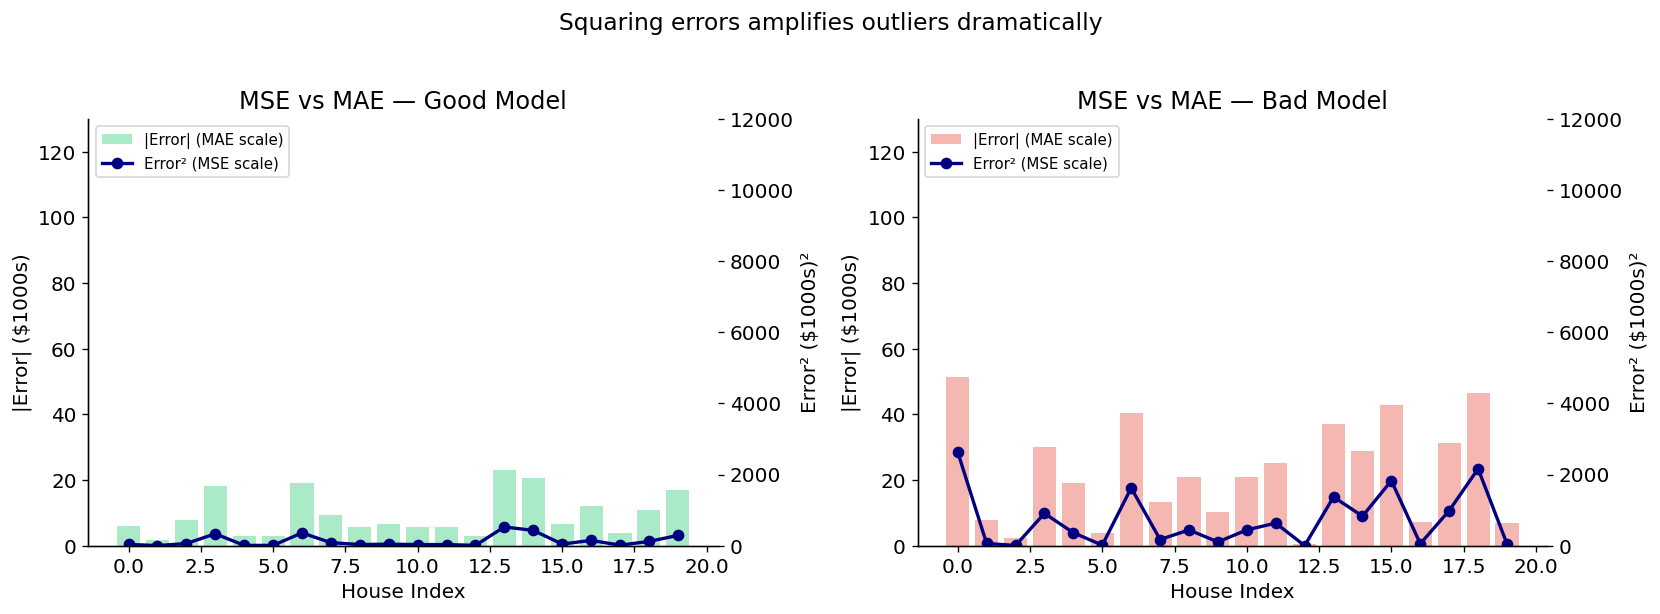

💡 Notice the navy line SPIKES on big errors — that is MSE punishing outliers.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sq_err, abs_err, label, color in zip(
        axes,
        [sq_errors_good, sq_errors_bad],
        [errors_good, errors_bad],
        ['Good Model', 'Bad Model'],
        ['#2ecc71', '#e74c3c']):
    
    ax2 = ax.twinx()
    ax.bar(range(n), abs_err, color=color, alpha=0.4, label='|Error| (MAE scale)')
    ax2.plot(range(n), sq_err, 'o-', color='navy', lw=2, label='Error² (MSE scale)')
    ax.set(title=f'MSE vs MAE — {label}', xlabel='House Index',
           ylabel='|Error| ($1000s)', ylim=(0, 130))
    ax2.set(ylabel='Error² ($1000s)²', ylim=(0, 12000))
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.suptitle('Squaring errors amplifies outliers dramatically', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print('💡 Notice the navy line SPIKES on big errors — that is MSE punishing outliers.')

---
## 📏 Section 4 — Root Mean Squared Error (RMSE)

### 🧠 Intuition
> *"MSE is great for math, but the units are squared and confusing. Just take the square root to get back to the original units!"*

### 📐 Formula
$$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

### ✅ RMSE vs MAE — When to Use Which?
| | MAE | RMSE |
|--|-----|------|
| Units | Same as target ✅ | Same as target ✅ |
| Outlier penalty | Equal weight | Heavy penalty |
| Use case | Robust metric | When big errors are especially costly |
| Always true | RMSE ≥ MAE | RMSE ≥ MAE |

In [8]:
rmse_good = np.sqrt(mse_good)
rmse_bad  = np.sqrt(mse_bad)

print('📊 All Three Metrics Side by Side:')
summary = pd.DataFrame({
    'Metric': ['MAE ($1000s)', 'MSE ($1000s)²', 'RMSE ($1000s)'],
    'Good Model': [f'{mae_good:.2f}', f'{mse_good:.1f}', f'{rmse_good:.2f}'],
    'Bad Model':  [f'{mae_bad:.2f}',  f'{mse_bad:.1f}',  f'{rmse_bad:.2f}'],
})
print(summary.to_string(index=False))

print(f'\n💡 Note: RMSE ({rmse_good:.1f}) > MAE ({mae_good:.1f}) for the good model')
print(f'   RMSE ({rmse_bad:.1f}) >> MAE ({mae_bad:.1f}) for the bad model — outliers inflate RMSE!')

📊 All Three Metrics Side by Side:
       Metric Good Model Bad Model
 MAE ($1000s)       9.39     22.33
MSE ($1000s)²      130.3     733.9
RMSE ($1000s)      11.42     27.09

💡 Note: RMSE (11.4) > MAE (9.4) for the good model
   RMSE (27.1) >> MAE (22.3) for the bad model — outliers inflate RMSE!


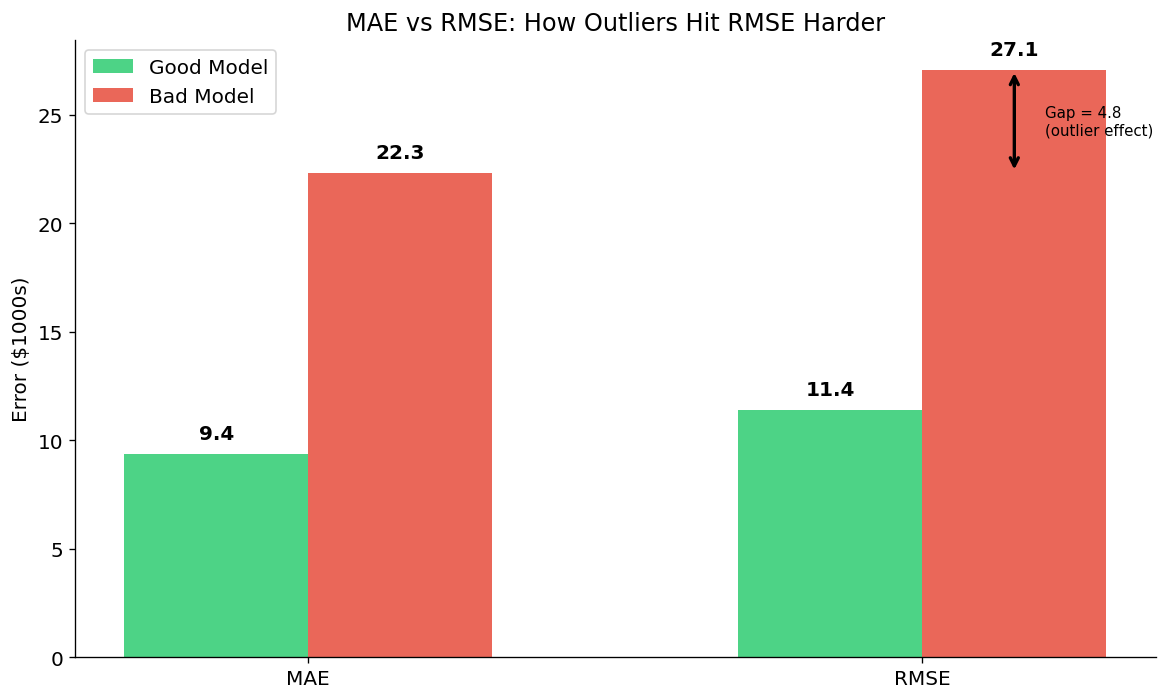

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['MAE', 'RMSE']
good_vals = [mae_good, rmse_good]
bad_vals  = [mae_bad,  rmse_bad]

x = np.array([0, 1])
w = 0.3
bars1 = ax.bar(x - w/2, good_vals, w, label='Good Model', color='#2ecc71', alpha=0.85)
bars2 = ax.bar(x + w/2, bad_vals,  w, label='Bad Model',  color='#e74c3c', alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontweight='bold')

ax.set(xticks=x, xticklabels=metrics, ylabel='Error ($1000s)',
       title='MAE vs RMSE: How Outliers Hit RMSE Harder')
ax.legend()

# Annotate the gap
ax.annotate('', xy=(1+w/2, rmse_bad), xytext=(1+w/2, mae_bad),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(1+w/2+0.05, (rmse_bad+mae_bad)/2,
        f'Gap = {rmse_bad-mae_bad:.1f}\n(outlier effect)', fontsize=9, va='center')

plt.tight_layout()
plt.show()

---
## 🎯 Section 5 — R² (Coefficient of Determination)

### 🧠 Intuition
> *"How much of the variation in house prices does our model explain?"*
> 
> Compare: **model errors** vs **just predicting the mean every time**.

### 📐 Formula
$$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

Where:
- $\text{SS}_{\text{res}}$ = Residual Sum of Squares (model errors)
- $\text{SS}_{\text{tot}}$ = Total Sum of Squares (baseline: always predict mean)

### 📊 Interpreting R²
| R² Value | Meaning |
|----------|---------|
| 1.0 | Perfect predictions |
| 0.8 | Model explains 80% of variance |
| 0.0 | No better than guessing the mean |
| < 0 | Worse than always predicting the mean! |

In [10]:
y_mean = y_true.mean()
SS_tot  = ((y_true - y_mean)**2).sum()
SS_res_good = ((y_true - y_good)**2).sum()
SS_res_bad  = ((y_true - y_bad)**2).sum()

r2_good = 1 - SS_res_good / SS_tot
r2_bad  = 1 - SS_res_bad  / SS_tot

print('=== R² Step-by-Step ===')
print(f'Mean of true prices: ȳ = {y_mean:.1f}')
print(f'SS_total  = {SS_tot:.1f}   (variance in actual data)')
print(f'SS_res (Good) = {SS_res_good:.1f}')
print(f'SS_res (Bad)  = {SS_res_bad:.1f}\n')
print(f'🟢 Good Model R² = 1 - {SS_res_good:.1f}/{SS_tot:.1f} = {r2_good:.4f}')
print(f'   → Model explains {r2_good*100:.1f}% of price variation')
print(f'🔴 Bad  Model R² = 1 - {SS_res_bad:.1f}/{SS_tot:.1f} = {r2_bad:.4f}')
print(f'   → Model explains only {r2_bad*100:.1f}% of price variation')

=== R² Step-by-Step ===
Mean of true prices: ȳ = 223.5
SS_total  = 43055.0   (variance in actual data)
SS_res (Good) = 2606.2
SS_res (Bad)  = 14678.5

🟢 Good Model R² = 1 - 2606.2/43055.0 = 0.9395
   → Model explains 93.9% of price variation
🔴 Bad  Model R² = 1 - 14678.5/43055.0 = 0.6591
   → Model explains only 65.9% of price variation


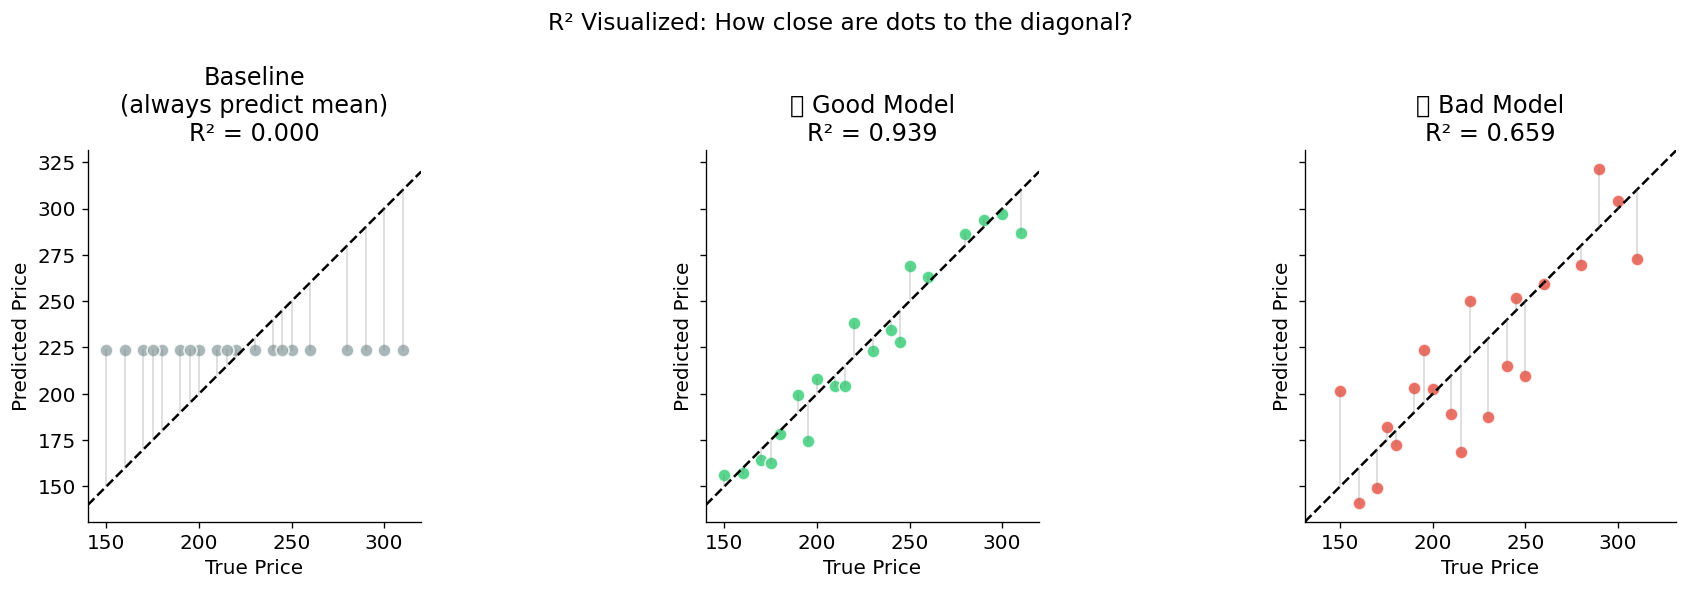

💡 Perfect model = all dots ON the dashed line. R²=1.0
   Baseline = horizontal cloud of dots. R²=0.0


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

scenarios = [
    ('Baseline\n(always predict mean)', np.full(n, y_mean), '#95a5a6'),
    ('🟢 Good Model',                   y_good,             '#2ecc71'),
    ('🔴 Bad Model',                    y_bad,              '#e74c3c'),
]

for ax, (title, y_pred, color) in zip(axes, scenarios):
    r2 = r2_score(y_true, y_pred)
    ax.scatter(y_true, y_pred, color=color, alpha=0.8, s=60, edgecolors='white')
    lims = [min(y_true.min(), y_pred.min())-10, max(y_true.max(), y_pred.max())+10]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect fit')
    for yt, yp in zip(y_true, y_pred):
        ax.plot([yt, yt], [yt, yp], color='gray', alpha=0.3, lw=1)
    ax.set(xlim=lims, ylim=lims, xlabel='True Price', ylabel='Predicted Price',
           title=f'{title}\nR² = {r2:.3f}')
    ax.set_aspect('equal')

plt.suptitle('R² Visualized: How close are dots to the diagonal?', fontsize=14)
plt.tight_layout()
plt.show()
print('💡 Perfect model = all dots ON the dashed line. R²=1.0')
print('   Baseline = horizontal cloud of dots. R²=0.0')

---
## 📊 Section 6 — Complete Metrics Dashboard
### All 4 Metrics Together

In [12]:
results = pd.DataFrame({
    'Model':  ['🟢 Good Model', '🔴 Bad Model'],
    'MAE':    [mae_good,  mae_bad],
    'MSE':    [mse_good,  mse_bad],
    'RMSE':   [rmse_good, rmse_bad],
    'R²':     [r2_good,   r2_bad],
})
print('📋 Final Metrics Summary:')
print(results.set_index('Model').round(3).to_string())

📋 Final Metrics Summary:
                 MAE      MSE    RMSE     R²
Model                                       
🟢 Good Model   9.391  130.308  11.415  0.939
🔴 Bad Model   22.332  733.927  27.091  0.659


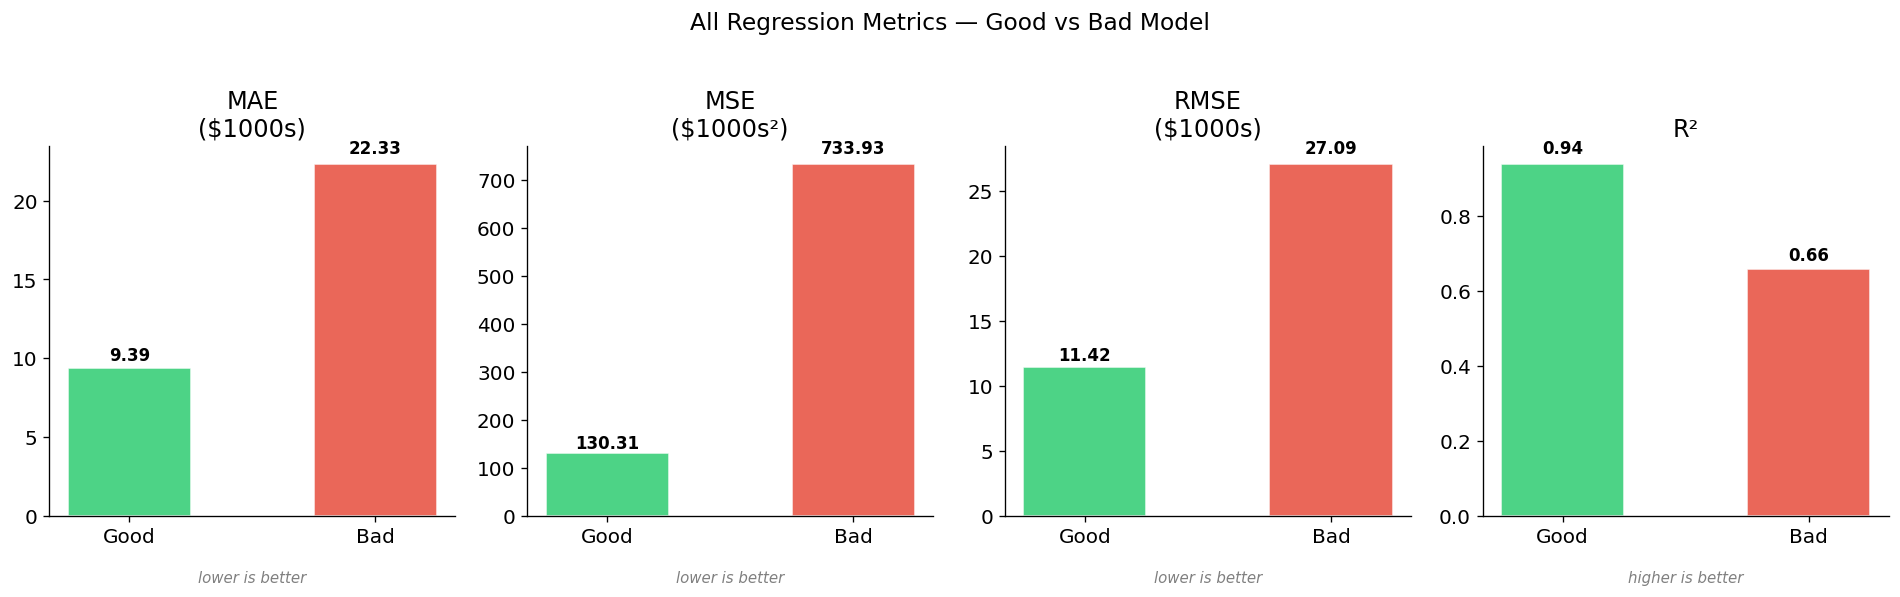

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

metrics_info = [
    ('MAE\n($1000s)',  [mae_good,  mae_bad],  'lower is better', False),
    ('MSE\n($1000s²)', [mse_good,  mse_bad],  'lower is better', False),
    ('RMSE\n($1000s)', [rmse_good, rmse_bad], 'lower is better', False),
    ('R²',             [r2_good,   r2_bad],   'higher is better', True),
]

for ax, (title, vals, note, higher_better) in zip(axes, metrics_info):
    colors = (['#2ecc71', '#e74c3c'] if not higher_better else
              (['#2ecc71', '#e74c3c'] if vals[0] > vals[1] else ['#e74c3c','#2ecc71']))
    bars = ax.bar(['Good', 'Bad'], vals, color=colors, alpha=0.85, width=0.5, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set(title=title, ylabel='')
    ax.text(0.5, -0.18, note, transform=ax.transAxes,
            ha='center', fontsize=9, color='gray', style='italic')

plt.suptitle('All Regression Metrics — Good vs Bad Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 🔄 Section 7 — Cross-Validation: Making Metrics Reliable

### 🚨 The Problem with a Single Train/Test Split

Imagine evaluating a student on **one exam only**:
- What if they got lucky? (or unlucky?)
- One exam score is not reliable evidence of true knowledge.

Same problem with models: **one test set might be lucky!**

### ✅ Solution: K-Fold Cross-Validation

1. Split all data into **K equal chunks (folds)**
2. Train on K−1 folds, test on 1 fold
3. Rotate: repeat K times so every fold is the test set once
4. Average all K scores → **reliable metric**

```
K=5 Folds:
Fold 1: [TEST] [train] [train] [train] [train]
Fold 2: [train] [TEST] [train] [train] [train]
Fold 3: [train] [train] [TEST] [train] [train]
Fold 4: [train] [train] [train] [TEST] [train]
Fold 5: [train] [train] [train] [train] [TEST]
```

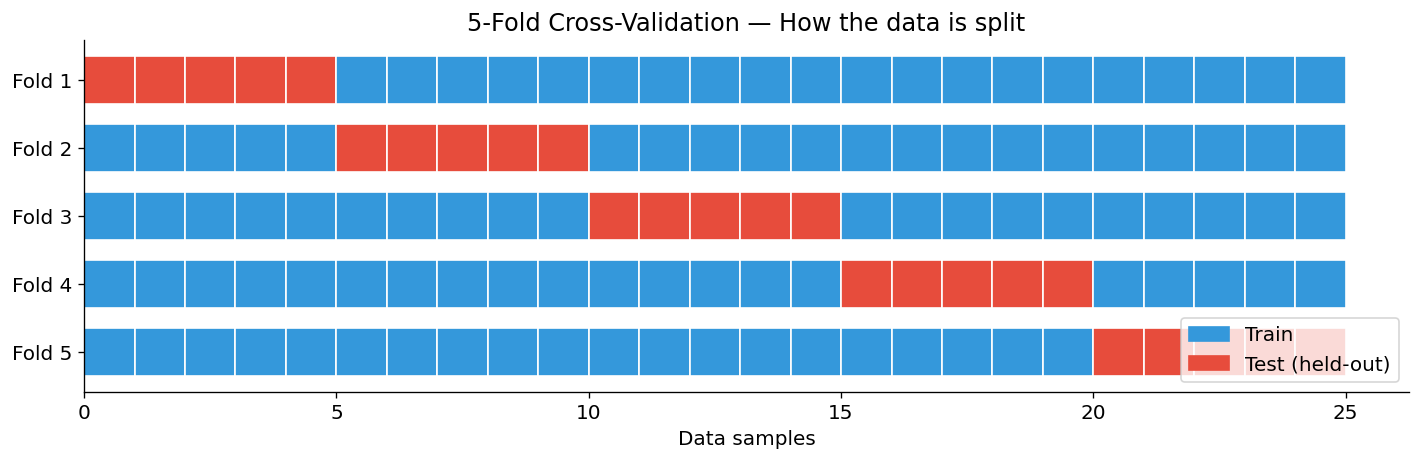

💡 Red = held-out test fold. Every sample gets tested exactly once!


In [14]:
# Visualize K-Fold splitting
fig, ax = plt.subplots(figsize=(12, 4))

n_splits = 5
n_samples = 25
colors_map = {True: '#e74c3c', False: '#3498db'}

kf = KFold(n_splits=n_splits, shuffle=False)
dummy_X = np.zeros(n_samples)

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(dummy_X)):
    is_test = np.zeros(n_samples, dtype=bool)
    is_test[test_idx] = True
    for i in range(n_samples):
        c = '#e74c3c' if is_test[i] else '#3498db'
        ax.barh(fold_idx, 1, left=i, color=c, edgecolor='white', height=0.7)

ax.set(yticks=range(n_splits), yticklabels=[f'Fold {i+1}' for i in range(n_splits)],
       xlabel='Data samples', title='5-Fold Cross-Validation — How the data is split')
ax.invert_yaxis()
patch_train = mpatches.Patch(color='#3498db', label='Train')
patch_test  = mpatches.Patch(color='#e74c3c', label='Test (held-out)')
ax.legend(handles=[patch_train, patch_test], loc='lower right')
plt.tight_layout()
plt.show()
print('💡 Red = held-out test fold. Every sample gets tested exactly once!')

In [15]:
# Use California Housing for a real CV demo
housing = fetch_california_housing()
X_cal = housing.data
y_cal = housing.target

scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

model = LinearRegression()

# Cross-validate with R² and MAE
cv_r2  = cross_val_score(model, X_cal_scaled, y_cal, cv=10, scoring='r2')
cv_mae = cross_val_score(model, X_cal_scaled, y_cal, cv=10,
                         scoring='neg_mean_absolute_error')
cv_mae = -cv_mae  # make positive

print('=== 10-Fold Cross-Validation on California Housing ===')
print(f'R² per fold:  {np.round(cv_r2, 3)}')
print(f'\nR²  → Mean: {cv_r2.mean():.4f}  |  Std: {cv_r2.std():.4f}')
print(f'MAE → Mean: {cv_mae.mean():.4f} |  Std: {cv_mae.std():.4f}')
print(f'\n💡 Std tells you HOW STABLE the metric is across folds.')
print(f'   Low std ({cv_r2.std():.3f}) = metric is reliable, not just lucky!')

=== 10-Fold Cross-Validation on California Housing ===
R² per fold:  [0.483 0.614 0.423 0.482 0.557 0.541 0.475 0.458 0.482 0.595]

R²  → Mean: 0.5110  |  Std: 0.0593
MAE → Mean: 0.5445 |  Std: 0.0911

💡 Std tells you HOW STABLE the metric is across folds.
   Low std (0.059) = metric is reliable, not just lucky!


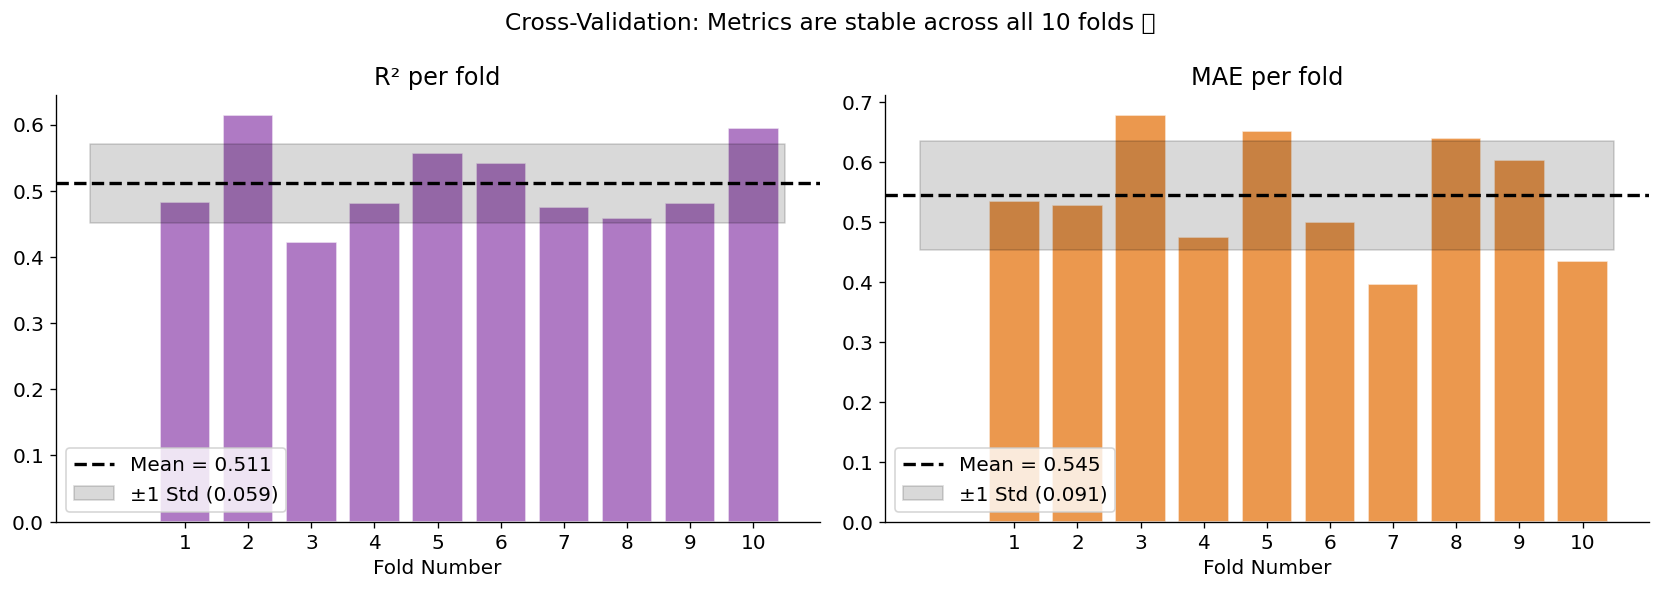

💡 If one fold gave a wildly different score, we should investigate that data split!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, name, color in zip(
        axes,
        [cv_r2, cv_mae],
        ['R² per fold', 'MAE per fold'],
        ['#9b59b6', '#e67e22']):
    
    ax.bar(range(1, 11), scores, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(scores.mean(), color='black', lw=2, ls='--',
               label=f'Mean = {scores.mean():.3f}')
    ax.fill_between([-0.5, 10.5],
                    scores.mean() - scores.std(),
                    scores.mean() + scores.std(),
                    alpha=0.15, color='black', label=f'±1 Std ({scores.std():.3f})')
    ax.set(title=name, xlabel='Fold Number', xticks=range(1,11))
    ax.legend()

plt.suptitle('Cross-Validation: Metrics are stable across all 10 folds ✅', fontsize=14)
plt.tight_layout()
plt.show()
print('💡 If one fold gave a wildly different score, we should investigate that data split!')

---
## ⚠️ Section 8 — Single Split vs Cross-Validation: The Danger Demo

Let's prove that a **single train/test split can mislead you** by showing how the score changes with different random seeds.

In [17]:
from sklearn.model_selection import train_test_split

single_split_r2 = []
for seed in range(50):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_cal_scaled, y_cal, test_size=0.2, random_state=seed)
    model.fit(X_tr, y_tr)
    single_split_r2.append(r2_score(y_te, model.predict(X_te)))

print('=== Single Split Instability ===')
print(f'50 different random splits gave R² ranging from:')
print(f'  Min: {min(single_split_r2):.4f}')
print(f'  Max: {max(single_split_r2):.4f}')
print(f'  Std: {np.std(single_split_r2):.4f}  ← unreliable!')
print(f'\n Cross-Val R² (10-fold): {cv_r2.mean():.4f} ± {cv_r2.std():.4f} ← trustworthy!')

=== Single Split Instability ===
50 different random splits gave R² ranging from:
  Min: 0.5721
  Max: 0.6256
  Std: 0.0125  ← unreliable!

 Cross-Val R² (10-fold): 0.5110 ± 0.0593 ← trustworthy!


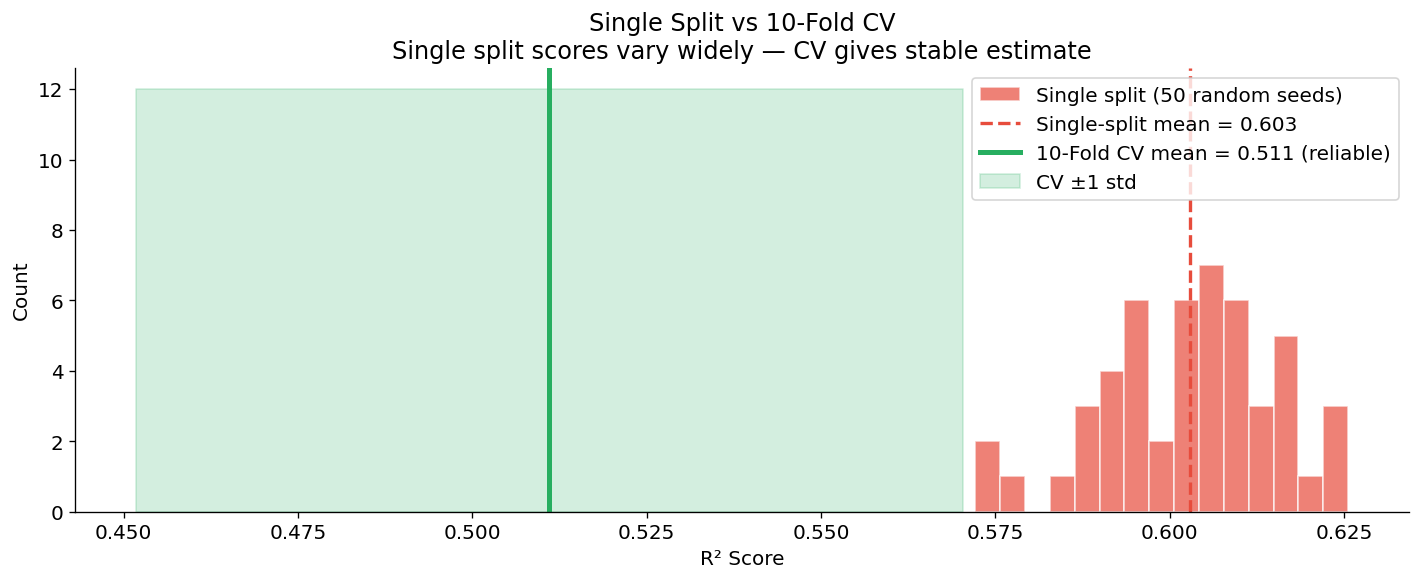

💡 Getting R²=0.62 with one split and R²=0.58 with another is NOT the model improving —
   it is just luck of the draw! Cross-validation removes that luck.


In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(single_split_r2, bins=15, color='#e74c3c', alpha=0.7,
        label='Single split (50 random seeds)', edgecolor='white')

ax.axvline(np.mean(single_split_r2), color='#e74c3c', lw=2, ls='--',
           label=f'Single-split mean = {np.mean(single_split_r2):.3f}')

ax.axvline(cv_r2.mean(), color='#27ae60', lw=3,
           label=f'10-Fold CV mean = {cv_r2.mean():.3f} (reliable)')

ax.fill_betweenx([0, 12], cv_r2.mean()-cv_r2.std(), cv_r2.mean()+cv_r2.std(),
                 alpha=0.2, color='#27ae60', label='CV ±1 std')

ax.set(xlabel='R² Score', ylabel='Count', 
       title='Single Split vs 10-Fold CV\nSingle split scores vary widely — CV gives stable estimate')
ax.legend()
plt.tight_layout()
plt.show()
print('💡 Getting R²=0.62 with one split and R²=0.58 with another is NOT the model improving —')
print('   it is just luck of the draw! Cross-validation removes that luck.')

---
## 🧾 Section 9 — Cheat Sheet & Final Summary

### 📌 Quick Reference: When to Use Which Metric

| Metric | Formula | Units | Outlier Sensitivity | Best Use Case |
|--------|---------|-------|---------------------|---------------|
| **MAE** | avg\|error\| | Same as target | Low | Easy communication, robust evaluation |
| **MSE** | avg(error²) | Squared | High | Training loss, math optimization |
| **RMSE** | √MSE | Same as target | High | When large errors are costly |
| **R²** | 1−SS_res/SS_tot | None (0–1) | Medium | Comparing models, % variance explained |

### 📌 Cross-Validation Rules of Thumb

| Situation | Recommendation |
|-----------|---------------|
| Default | **5-fold or 10-fold CV** |
| Small dataset (<500 rows) | **Leave-One-Out (LOO-CV)** |
| Time-series data | **TimeSeriesSplit** (no shuffling!) |
| Reporting a model | Always report **mean ± std** of CV score |

In [19]:
# Final all-in-one function
def evaluate_regression_model(y_true, y_pred, model_name='Model', cv_scores=None):
    """Complete regression evaluation report."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    
    print(f'{'='*40}')
    print(f'  📊 Evaluation Report: {model_name}')
    print(f'{'='*40}')
    print(f'  MAE  = {mae:.4f}  (avg error magnitude)')
    print(f'  MSE  = {mse:.4f}  (penalizes big errors)')
    print(f'  RMSE = {rmse:.4f}  (interpretable, same units)')
    print(f'  R²   = {r2:.4f}  ({r2*100:.1f}% of variance explained)')
    if cv_scores is not None:
        print(f'  CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  (reliable estimate)')
    print(f'{'='*40}')
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

# Fit final model and evaluate
model.fit(X_cal_scaled, y_cal)
y_final_pred = model.predict(X_cal_scaled)
evaluate_regression_model(y_cal, y_final_pred,
                           model_name='California Housing — Linear Regression',
                           cv_scores=cv_r2)
print('\n🎓 Lecture Complete! You now know how to measure AND trust regression models.')

  📊 Evaluation Report: California Housing — Linear Regression
  MAE  = 0.5312  (avg error magnitude)
  MSE  = 0.5243  (penalizes big errors)
  RMSE = 0.7241  (interpretable, same units)
  R²   = 0.6062  (60.6% of variance explained)
  CV R² = 0.5110 ± 0.0593  (reliable estimate)

🎓 Lecture Complete! You now know how to measure AND trust regression models.
